In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configuración
semanas = 52
dias_simulacion = semanas * 7
fecha_inicio = datetime(2023, 12, 31) 
densidad_std = 1.030
nombre_fichero = 'datos/queseria_final_tidy.csv'

dias_es = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

data = []
stock_leche_litros = 0.0
stock_grasa_kg_total = 0.0
stock_proteina_kg_total = 0.0

for i in range(dias_simulacion):
    fecha = fecha_inicio + timedelta(days=i)
    num_dia = fecha.weekday() 
    
    entrada_kg, entrada_litros, grasa_g_l, prot_g_l = 0, 0, 0.0, 0.0
    
    # 1. ENTRADAS
    if num_dia in [6, 0, 1, 2, 3]:
        entrada_kg = int(round(np.random.normal(5150, 300))) 
        entrada_litros = int(round(entrada_kg / densidad_std))
        grasa_g_l = np.random.normal(42.40, 1.5)
        prot_g_l = np.random.normal(35.68, 1.0)
        
        stock_leche_litros += entrada_litros
        stock_grasa_kg_total += (entrada_litros * grasa_g_l) / 1000
        stock_proteina_kg_total += (entrada_litros * prot_g_l) / 1000

    # 2. FABRICACIÓN
    cuba_litros_final, cuba_grasa_g_l, cuba_prot_g_l = 0, 0.0, 0.0
    queso_est_pct, queso_mg_pct, queso_esm_pct, queso_hqd_pct = 0.0, 0.0, 0.0, 0.0
    queso_kg, queso_est_kg, queso_mg_kg, queso_esm_kg,  = 0.0, 0.0, 0.0, 0.0
    suero_litros, suero_grasa_g_l, suero_prot_g_l, suero_es_g_l = 0.0, 0.0, 0.0, 0.0
    cuba_grasa_kg, cuba_prot_kg, cuba_fab_grasa_kg, cuba_fab_prot_kg = 0.0, 0.0, 0.0, 0.0
    recup_mg, recup_mp, consumo_mg, consumo_mp = 0.0, 0.0, 0.0, 0.0
    
    if num_dia in [0, 1, 2, 3, 4]: # lunes a viernes
        if num_dia == 4:
            cuba_litros_teoricos = stock_leche_litros
        else:
            cuba_litros_teoricos = 5000.0 if stock_leche_litros >= 5000 else stock_leche_litros

        if stock_leche_litros > 0 and cuba_litros_teoricos > 0:
            factor = (cuba_litros_teoricos / stock_leche_litros)
            kg_grasa_t = stock_grasa_kg_total * factor
            kg_prot_t = stock_proteina_kg_total * factor
            
            perdida_mg_dia = np.random.normal(0.04, 0.005)
            perdida_mp_dia = np.random.normal(0.04, 0.005)
            inc_agua_dia = np.random.normal(0.005, 0.001)
            
            cuba_litros_final = int(round(cuba_litros_teoricos * (1 + inc_agua_dia)))
            cuba_grasa_g_l = (kg_grasa_t * (1 - perdida_mg_dia) * 1000) / cuba_litros_final
            cuba_prot_g_l = (kg_prot_t * (1 - perdida_mp_dia) * 1000) / cuba_litros_final
            cuba_grasa_kg = cuba_litros_final * cuba_grasa_g_l /1000
            cuba_prot_kg = cuba_litros_final * cuba_prot_g_l /1000
            
            # --- NUEVA LÓGICA DE RATIO ALEATORIA ---
            # 1. EST: Base fija de 52.0 (Media anual garantizada)
            desviacion_est = np.random.normal(0, 1.2)
            queso_est_pct = 52.0 + desviacion_est
            
            # 2. Ratio L/kg: Base fija de 8.0 (Media anual garantizada)
            # Sube si el EST es alto (más concentración), baja si el EST es bajo.
            sensibilidad_ratio = 0.15 
            error_aleatorio_proceso = np.random.normal(0, 0.3)           
            ratio_dia = 8.0 + (queso_est_pct - 52.0) * sensibilidad_ratio + error_aleatorio_proceso
            
            # --- 3. KILOS DE QUESO ---
            queso_kg = cuba_litros_final / ratio_dia
            
            # --- 4. MG (MATERIA GRASA DEL QUESO) ---
            factor_correlacion_grasa = 0.4  
            ruido_grasa = np.random.normal(0, 0.5)
            queso_mg_pct = 27.0 + (queso_est_pct - 52.0) * factor_correlacion_grasa + ruido_grasa

            # --- 5. OTROS PARÁMETROS DEL QUESO (Derivados) ---
            queso_esm_pct = queso_est_pct - queso_mg_pct
            queso_hqd_pct = ((100-queso_est_pct)/(100-queso_mg_pct))*100

            queso_est_kg = queso_kg * queso_est_pct / 100
            queso_mg_kg = queso_kg * queso_mg_pct / 100
            queso_esm_kg = queso_kg * queso_esm_pct / 100
          
            # --- 6. BALANCES TÉCNICOS DE QUESO (Recuperaciones y Consumos) ---
            recup_mg = queso_mg_kg / cuba_grasa_kg * 100
            recup_mp = queso_esm_kg / cuba_prot_kg * 100
            consumo_mg = cuba_grasa_kg / queso_kg * 1000
            consumo_mp = cuba_prot_kg / queso_kg * 1000

        # --- 7. BALANCE DE SUERO (UNIDADES EN G/L) ---
            factor_perdida_invisible = np.random.normal(0.02, 0.005)
            cuba_masa_kg = cuba_litros_final * 1.030
            suero_masa_kg = cuba_masa_kg - queso_kg
            suero_litros = suero_masa_kg / 1.025
            
            # A. Grasa en suero (g/L)
            grasa_entrada_total_kg = (cuba_litros_final * cuba_grasa_g_l) / 1000
            grasa_en_suero_total = (grasa_entrada_total_kg - queso_mg_kg) * (1 - factor_perdida_invisible)
            suero_grasa_g_l = max(0, (grasa_en_suero_total * 1000) / suero_litros)

            # B. Proteína en suero (g/L)
            prot_en_queso_pct = 23.0 + np.random.normal(0, 0.5) 
            prot_en_queso_kg = queso_kg * (prot_en_queso_pct / 100)
            prot_entrada_total_kg = (cuba_litros_final * cuba_prot_g_l) / 1000
            prot_en_suero_total = (prot_entrada_total_kg - prot_en_queso_kg) * (1 - factor_perdida_invisible)
            suero_prot_g_l = max(0, (prot_en_suero_total * 1000) / suero_litros)

            # C. Extracto Seco del Suero (g/L)
            # Lactosa y sales: residuo constante en el suero (aprox 50-52 g/L)
            suero_esm_residuo_g_l = np.random.normal(51.0, 0.8)
            
            # El EST es la suma directa de todos los sólidos disueltos
            suero_es_g_l = suero_grasa_g_l + suero_prot_g_l + suero_esm_residuo_g_l

            # --- 8. ACTUALIZACIÓN DE STOCKS ---
            stock_leche_litros -= cuba_litros_teoricos
            stock_grasa_kg_total -= kg_grasa_t
            stock_proteina_kg_total -= kg_prot_t
            
    # 4. GUARDAR DATOS
    data.append({
        'fecha': fecha.strftime('%d/%m/%Y'),
        'entrada_kg': int(entrada_kg),
        'entrada_litros': int(entrada_litros),
        'entrada_grasa_g_l': round(grasa_g_l, 2),
        'entrada_prot_g_l': round(prot_g_l, 2),
        'cuba_fab_litros': int(cuba_litros_final),
        'cuba_fab_grasa_g_l': round(cuba_grasa_g_l, 2),
        'cuba_fab_prot_g_l': round(cuba_prot_g_l, 2),
        'stock_cierre_litros': int(round(max(0, stock_leche_litros))),
        'queso_kg': round(queso_kg, 2),
        'queso_est_pct': round(queso_est_pct, 2),
        'queso_mg_pct': round(queso_mg_pct, 2),
        'suero_litros': round(suero_litros, 0),
        'suero_grasa_g_l': round(suero_grasa_g_l, 2),
        'suero_prot_g_l': round(suero_prot_g_l, 2),
        'suero_es_g_l': round(suero_es_g_l, 2)

        # comentado para incluir en caso de necesitar debug
        # 'cuba_fab_grasa_kg': round(cuba_grasa_kg, 2),
        # 'cuba_fab_prot_kg': round(cuba_prot_kg, 2),        
        # 'queso_esm_pct': round(queso_esm_pct, 2),
        # 'queso_hqd_pct': round(queso_hqd_pct, 2),
        # 'queso_est_kg': round(queso_est_kg, 2),
        # 'queso_mg_kg': round(queso_mg_kg, 2),
        # 'queso_esm_kg': round(queso_esm_kg, 2),
        # 'recup_mg': round(recup_mg, 2),
        # 'recup_mp': round(recup_mp, 2),
        # 'consumo_mg': round(consumo_mg, 2),        
        # 'consumo_mp': round(consumo_mp, 2)
    })

df = pd.DataFrame(data)

# Reemplazamos todos los 0 por NaN para que el CSV los exporte como celdas vacías
#df = df.replace(0, np.nan)
# df.to_csv(nombre_fichero, index=False, sep=';', decimal=',', encoding='ISO-8859-1')
#print(f"Simulación completa con rendimiento variable. Archivo: {nombre_fichero}")

In [ ]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_style("whitegrid")

# Python concatena automáticamente estas cadenas en diferentes
# líneas, escritas así para que el formato en A4 no se
# desborde por la derecha.
url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/fab_queso_sim.csv"
)

try:
    df = pd.read_csv(url_datos, 
                     decimal = ",", 
                     sep=';', 
                     encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

In [16]:
df.head()

,fecha,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,cuba_fab_litros,cuba_fab_grasa_g_l,cuba_fab_prot_g_l,stock_cierre_litros,queso_kg,queso_est_pct,queso_mg_pct,suero_litros,suero_grasa_g_l,suero_prot_g_l,suero_es_g_l
0,31/12/2023,5150,5000,40.68,33.73,0,0.00,0.00,5000,0.00,0.00,0.00,0.0,0.00,0.00,0.00
1,01/01/2024,5412,5254,42.44,36.14,5029,39.97,33.21,5254,667.36,50.98,26.56,4402.0,5.25,3.54,60.93
2,02/01/2024,5453,5294,43.26,37.22,5023,40.65,34.68,5548,646.94,52.78,26.62,4416.0,7.11,6.90,66.14
3,03/01/2024,5303,5149,42.79,35.14,5024,40.78,33.73,5697,587.30,53.55,27.91,4476.0,8.91,7.53,67.07
4,04/01/2024,5599,5436,44.29,35.18,5022,41.54,33.89,6133,601.61,54.03,27.12,4460.0,10.07,7.09,67.98


In [17]:
# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y', # Formato Día/Mes/Año confirmado
    errors='coerce'    # convierte los valores que no puede leer a NaT
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

In [18]:
# Reemplazamos todos los 0 por NaN
df = df.replace(0, np.nan)

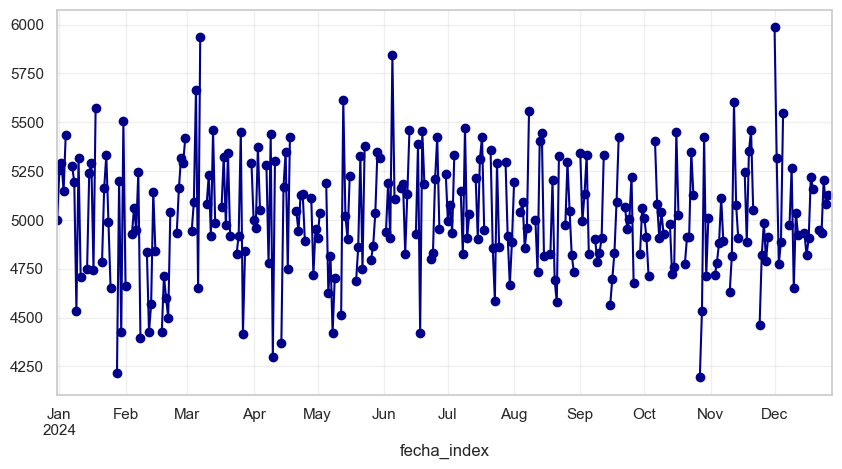

In [19]:
# Visualización
plt.figure(figsize=(8, 4))

df['entrada_litros'].plot(kind='line', marker='o', figsize=(10, 5), color='darkblue')
plt.grid(True, alpha=0.3)
plt.show()

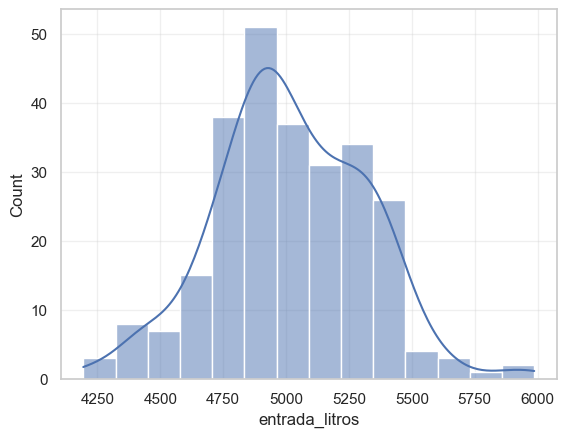

In [25]:
# Visualización
# plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='entrada_litros', kde=True)
plt.grid(True, alpha=0.3)
plt.show()

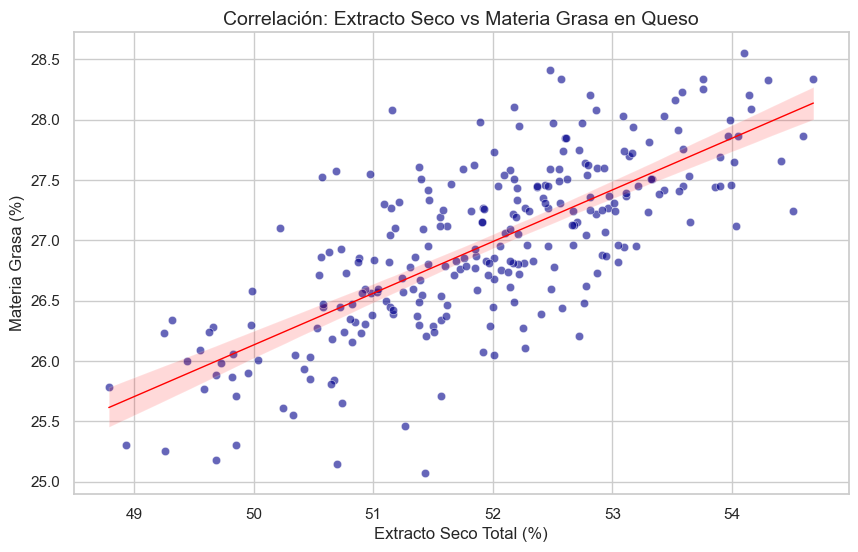

In [21]:
# 1. Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de dispersión (XY)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='queso_est_pct', 
    y='queso_mg_pct', 
    alpha=0.6,          # Transparencia para ver puntos solapados
    color='darkblue'
)

# 3. Añadimos una línea de tendencia (opcional pero muy útil)
sns.regplot(
    data=df, 
    x='queso_est_pct', 
    y='queso_mg_pct', 
    scatter=False,      # No dibuja los puntos otra vez
    color='red', 
    line_kws={"linewidth": 1}
)

# 4. Etiquetas y título
plt.title('Correlación: Extracto Seco vs Materia Grasa en Queso', fontsize=14)
plt.xlabel('Extracto Seco Total (%)')
plt.ylabel('Materia Grasa (%)')

plt.show()

In [23]:
df['rendim_l_kg'] = df['cuba_fab_litros']/df['queso_kg']

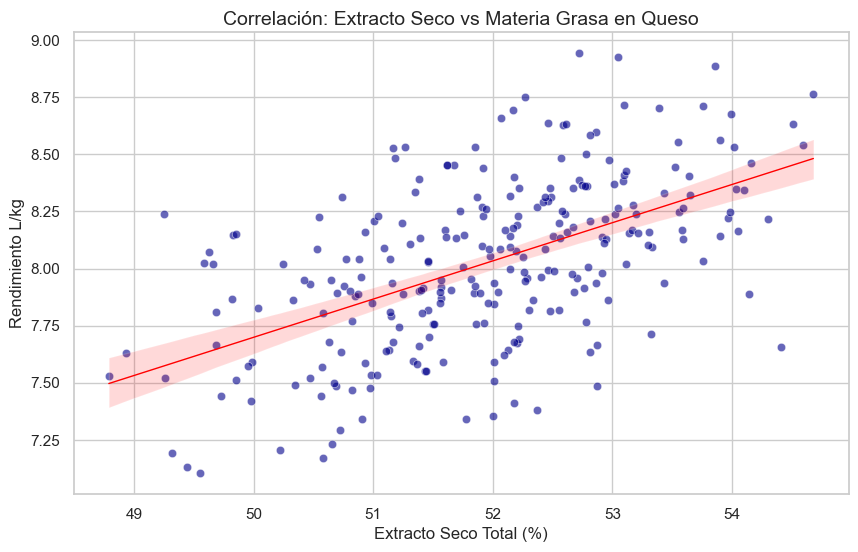

In [24]:
# 1. Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de dispersión (XY)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='queso_est_pct', 
    y='rendim_l_kg', 
    alpha=0.6,          # Transparencia para ver puntos solapados
    color='darkblue'
)

# 3. Añadimos una línea de tendencia (opcional pero muy útil)
sns.regplot(
    data=df, 
    x='queso_est_pct', 
    y='rendim_l_kg', 
    scatter=False,      # No dibuja los puntos otra vez
    color='red', 
    line_kws={"linewidth": 1}
)

# 4. Etiquetas y título
plt.title('Correlación: Extracto Seco vs Materia Grasa en Queso', fontsize=14)
plt.xlabel('Extracto Seco Total (%)')
plt.ylabel('Rendimiento L/kg')

plt.show()